## EDA

In [1]:
# LIBRERIAS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#CARGA DE DATOS

contract = pd.read_csv('/datasets/final_provider/contract.csv')
personal = pd.read_csv('/datasets/final_provider/personal.csv')
internet = pd.read_csv('/datasets/final_provider/internet.csv')
phone = pd.read_csv('/datasets/final_provider/phone.csv')



In [3]:
#DISPLAY DE LAS TABLAS
display(contract.head())
display(personal.head())
display(internet.head())
display(phone.head())

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,1889.5
2,3668-QPYBK,2019-10-01,2019-12-01 00:00:00,Month-to-month,Yes,Mailed check,53.85,108.15
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,9237-HQITU,2019-09-01,2019-11-01 00:00:00,Month-to-month,Yes,Electronic check,70.70,151.65


,customerID,gender,SeniorCitizen,Partner,Dependents
0,7590-VHVEG,Female,0,Yes,No
1,5575-GNVDE,Male,0,No,No
2,3668-QPYBK,Male,0,No,No
3,7795-CFOCW,Male,0,No,No
4,9237-HQITU,Female,0,No,No


,customerID,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,7590-VHVEG,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,DSL,Yes,Yes,No,No,No,No
3,7795-CFOCW,DSL,Yes,No,Yes,Yes,No,No
4,9237-HQITU,Fiber optic,No,No,No,No,No,No


,customerID,MultipleLines
0,5575-GNVDE,No
1,3668-QPYBK,No
2,9237-HQITU,No
3,9305-CDSKC,Yes
4,1452-KIOVK,Yes


In [4]:
#TAMAÑO DE CADA ARCHIVO
print("Dimensiones de contract:", contract.shape)
print("Dimensiones de personal:", personal.shape)
print("Dimensiones de internet:", internet.shape)
print("Dimensiones de phone:", phone.shape)

Dimensiones de contract: (7043, 8)
Dimensiones de personal: (7043, 5)
Dimensiones de internet: (5517, 8)
Dimensiones de phone: (6361, 2)


In [7]:
#COMBINACIÓN DE DATASETS
df = contract.merge(personal, on='customerID', how='left')
df = df.merge(internet, on='customerID', how='left')
df = df.merge(phone, on='customerID', how='left')
print("\nDimensiones totales después de unir:", df.shape)
display(df.head())



Dimensiones totales después de unir: (7043, 20)


,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,gender,SeniorCitizen,Partner,Dependents,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,MultipleLines
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,29.85,Female,0,Yes,No,DSL,No,Yes,No,No,No,No,NaN
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,1889.5,Male,0,No,No,DSL,Yes,No,Yes,No,No,No,No
2,3668-QPYBK,2019-10-01,2019-12-01 00:00:00,Month-to-month,Yes,Mailed check,53.85,108.15,Male,0,No,No,DSL,Yes,Yes,No,No,No,No,No
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.30,1840.75,Male,0,No,No,DSL,Yes,No,Yes,Yes,No,No,NaN
4,9237-HQITU,2019-09-01,2019-11-01 00:00:00,Month-to-month,Yes,Electronic check,70.70,151.65,Female,0,No,No,Fiber optic,No,No,No,No,No,No,No


In [8]:
#REVISIÓN DE DATOS
print("\nTipos de datos:")
print(df.dtypes.value_counts())

print("\nValores faltantes por columna:")
print(df.isna().sum())

print("\nNúmero de duplicados:", df.duplicated().sum())


Tipos de datos:
object     18
int64       1
float64     1
dtype: int64

Valores faltantes por columna:
customerID             0
BeginDate              0
EndDate                0
Type                   0
PaperlessBilling       0
PaymentMethod          0
MonthlyCharges         0
TotalCharges           0
gender                 0
SeniorCitizen          0
Partner                0
Dependents             0
InternetService     1526
OnlineSecurity      1526
OnlineBackup        1526
DeviceProtection    1526
TechSupport         1526
StreamingTV         1526
StreamingMovies     1526
MultipleLines        682
dtype: int64

Número de duplicados: 0


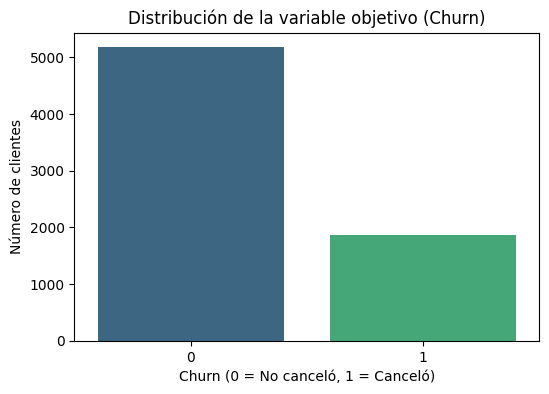

Tasa de cancelación: 26.54%


In [9]:
#VARIABLE OBJETIVO 
# Crear columna binaria 'Churn' (1 = canceló, 0 = sigue activo)
df['Churn'] = np.where(df['EndDate'] == 'No', 0, 1)

plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df, palette='viridis')
plt.title('Distribución de la variable objetivo (Churn)')
plt.xlabel('Churn (0 = No canceló, 1 = Canceló)')
plt.ylabel('Número de clientes')
plt.show()

print(f"Tasa de cancelación: {df['Churn'].mean() * 100:.2f}%")


Variables numéricas:
['MonthlyCharges', 'SeniorCitizen', 'Churn']


,MonthlyCharges,SeniorCitizen,Churn
count,7043.000000,7043.000000,7043.000000
mean,64.761692,0.162147,0.265370
std,30.090047,0.368612,0.441561
min,18.250000,0.000000,0.000000
25%,35.500000,0.000000,0.000000
50%,70.350000,0.000000,0.000000
75%,89.850000,0.000000,1.000000
max,118.750000,1.000000,1.000000


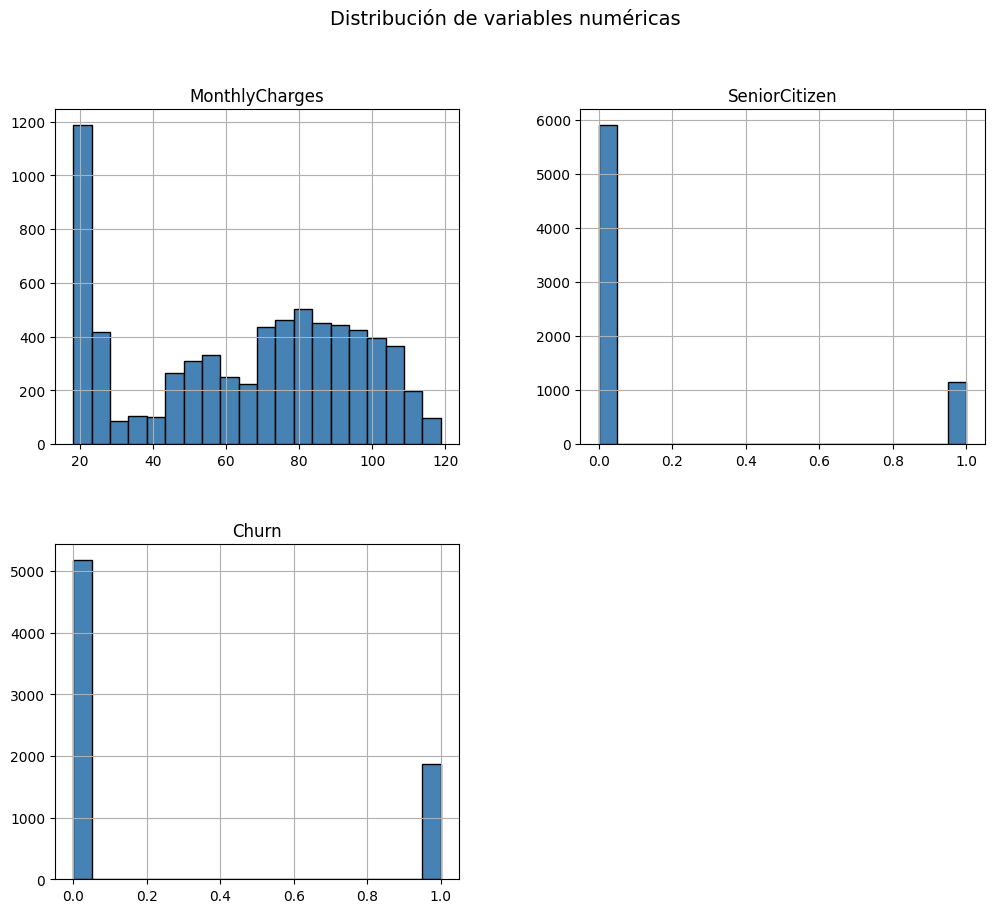

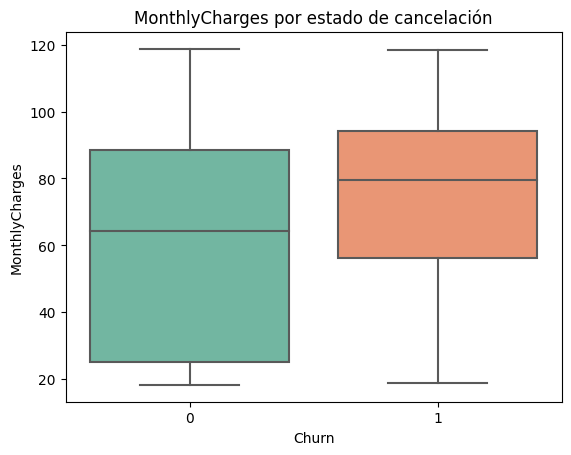

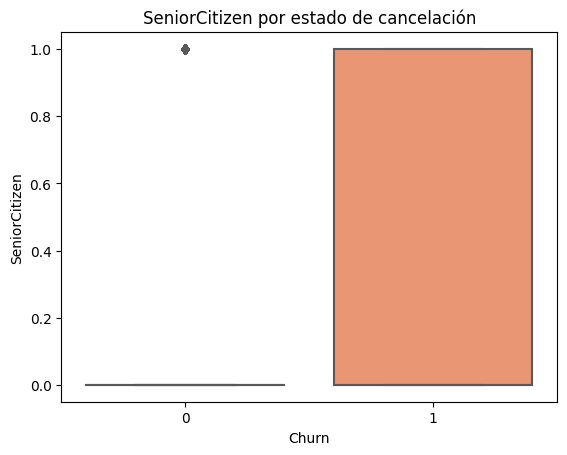

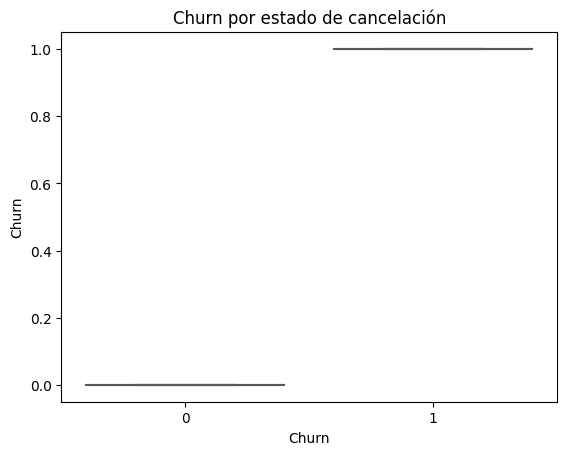

In [10]:
# VARIABLES NUMÉRICAS
num_cols = df.select_dtypes(include=np.number).columns

print("\nVariables numéricas:")
print(num_cols.tolist())

display(df[num_cols].describe())

# Histogramas
df[num_cols].hist(bins=20, figsize=(12, 10), color='steelblue', edgecolor='black')
plt.suptitle('Distribución de variables numéricas', fontsize=14)
plt.show()

# Boxplots por Churn
for col in num_cols:
    plt.figure()
    sns.boxplot(x='Churn', y=col, data=df, palette='Set2')
    plt.title(f'{col} por estado de cancelación')
    plt.show()



Variables categóricas:
['Type', 'PaperlessBilling', 'PaymentMethod', 'gender', 'Partner', 'Dependents', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'MultipleLines']


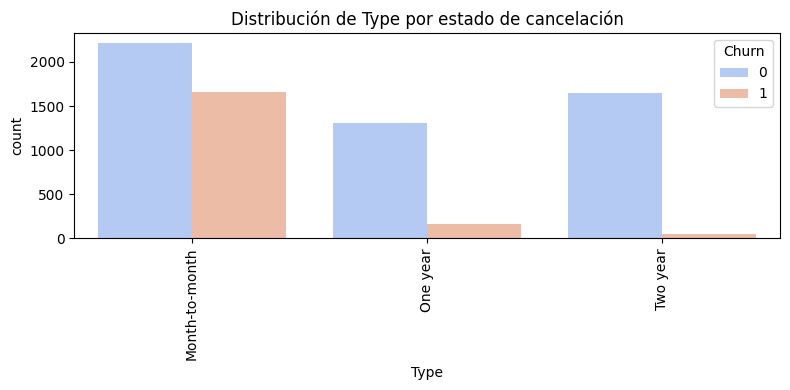

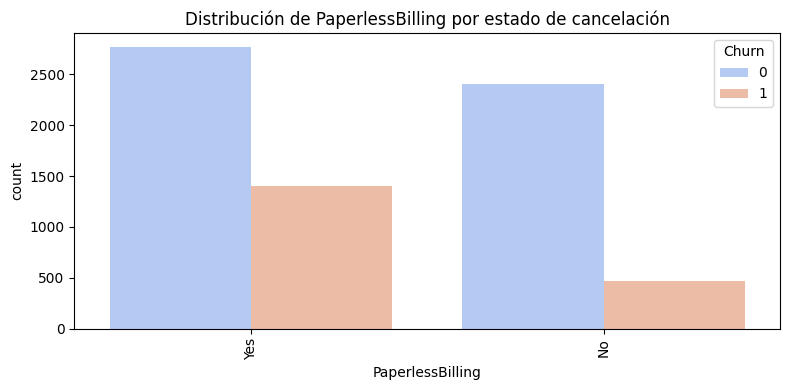

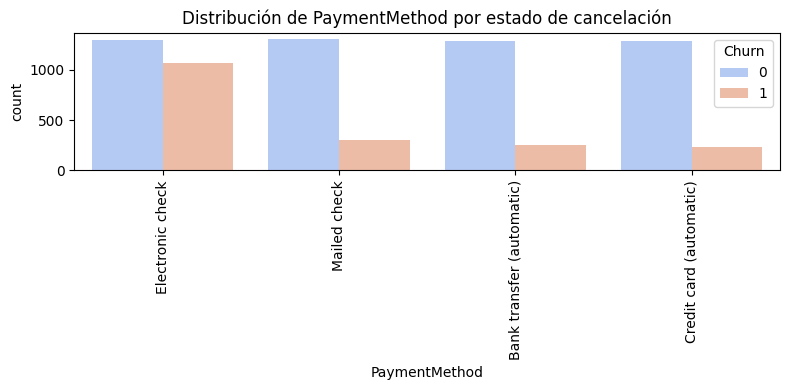

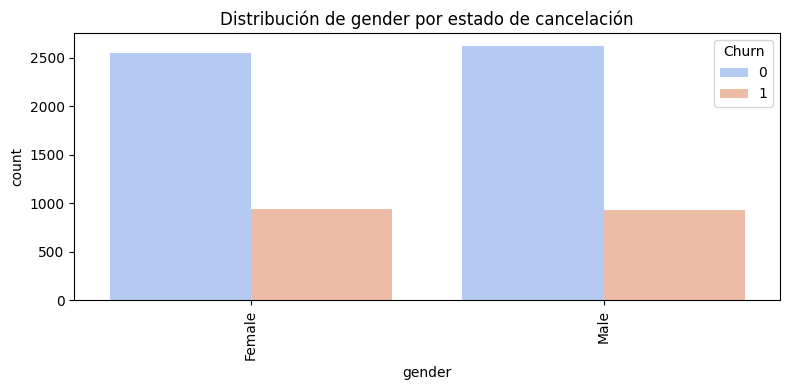

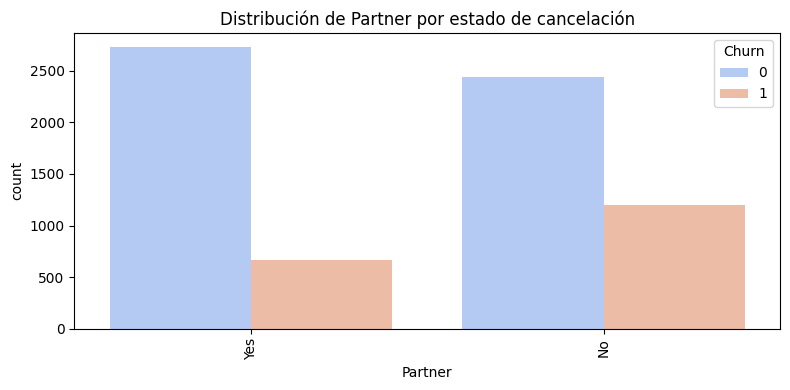

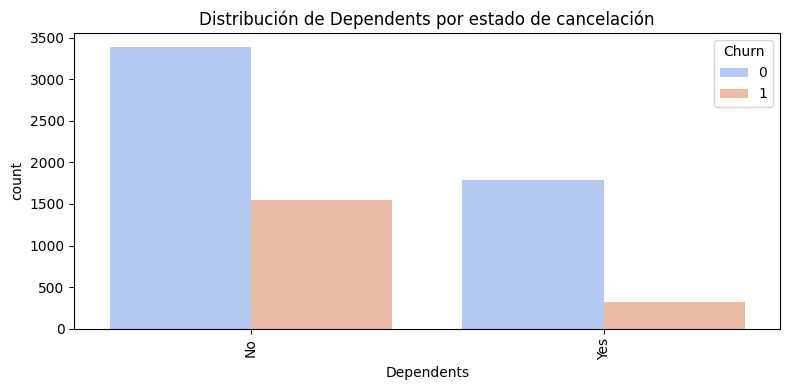

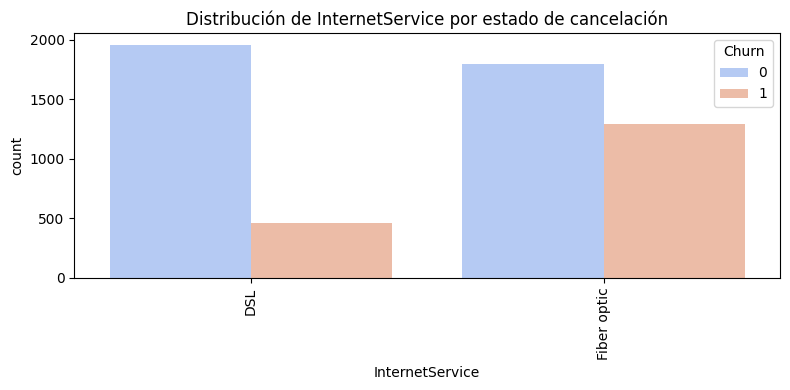

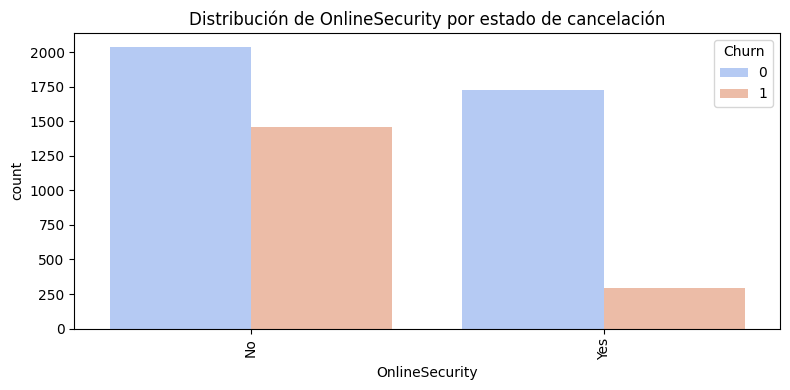

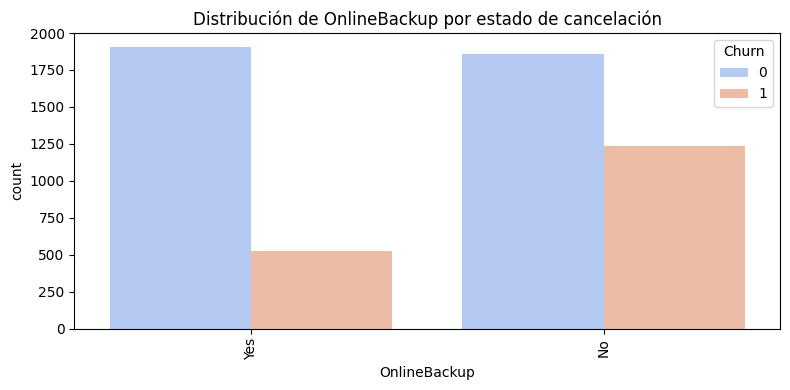

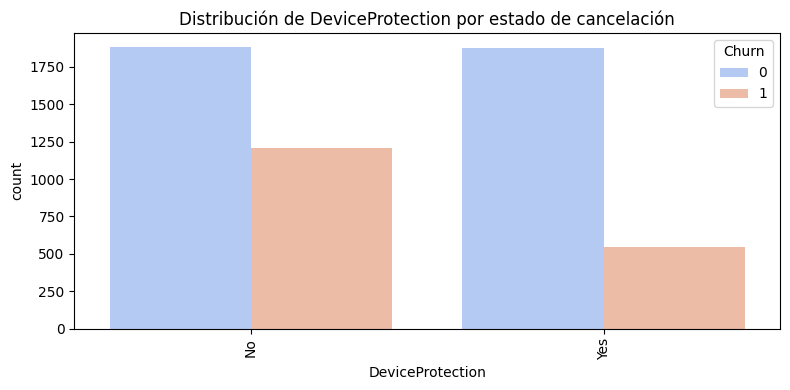

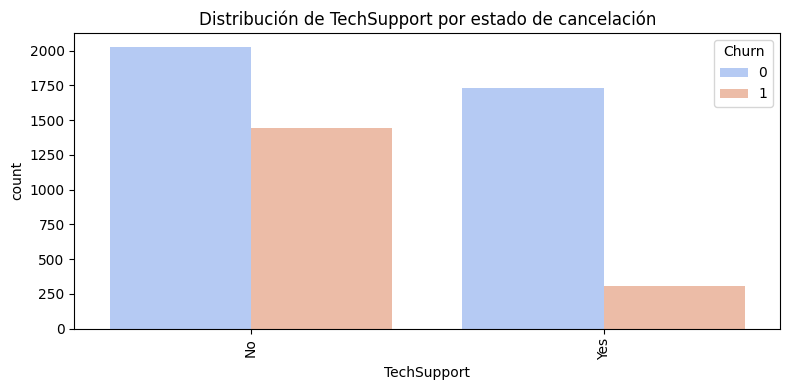

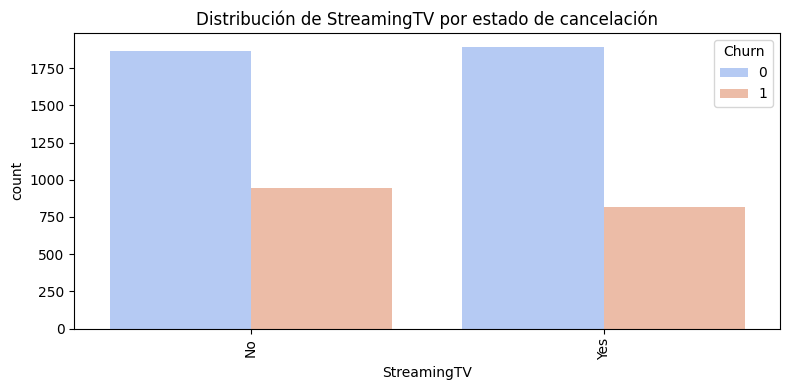

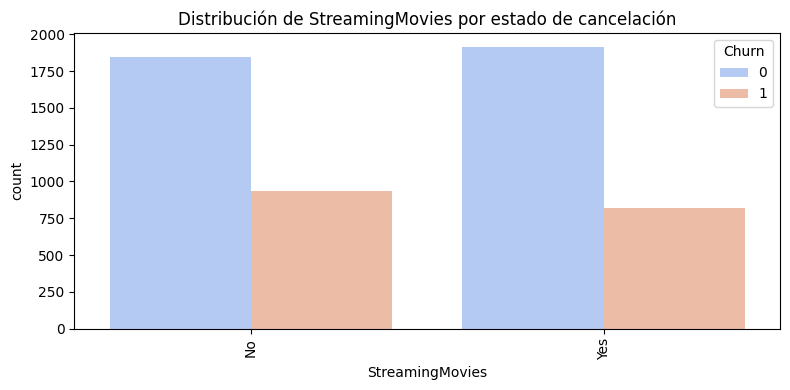

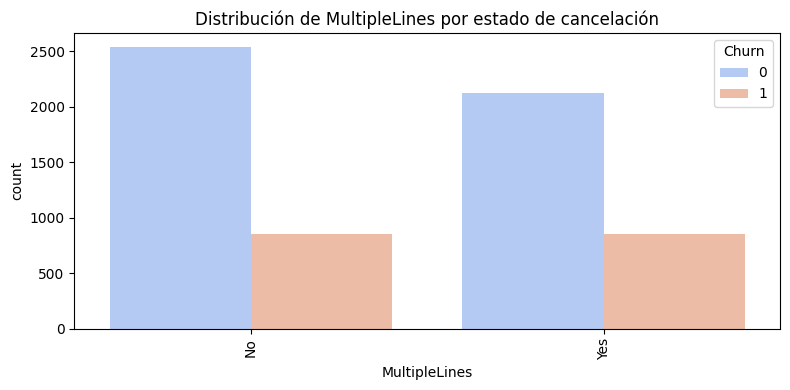

In [14]:
#VARIABLES CATEGÓRICAS
cat_cols = df.select_dtypes(include='object').columns.drop(['EndDate', 'customerID', 'BeginDate', 'TotalCharges'])

print("\nVariables categóricas:")
print(cat_cols.tolist())

for col in cat_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(x=col, data=df, hue='Churn', palette='coolwarm')
    plt.title(f'Distribución de {col} por estado de cancelación')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()


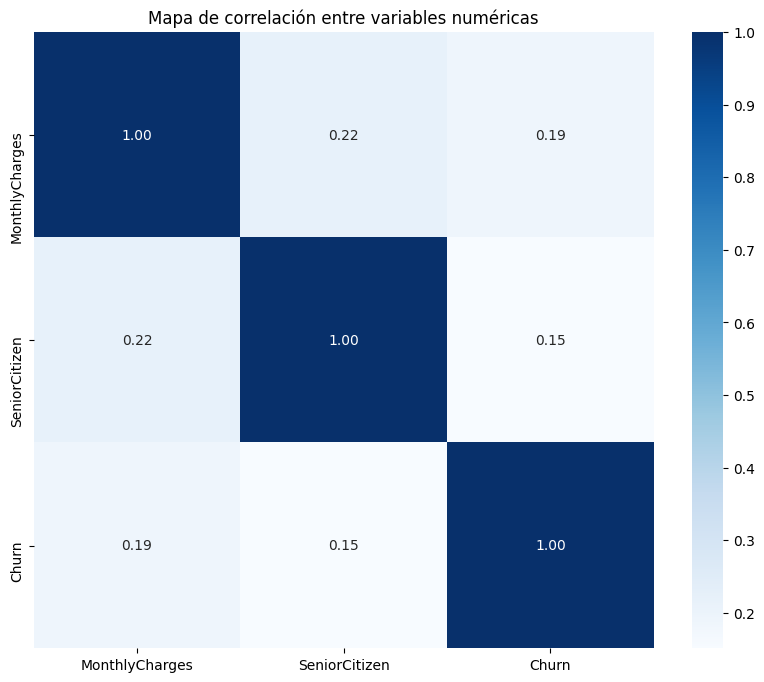

In [13]:
# CORRELACIONES
corr = df[num_cols].corr() 

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='Blues', fmt='.2f')
plt.title('Mapa de correlación entre variables numéricas')
plt.show()

##  Plan aproximado para resolver la tarea

1. **Cargar y revisar los datos**  
   Importar el conjunto de datos desde la ruta `/datasets/final_provider/`, visualizar las primeras filas y obtener información general sobre el tipo de variables, valores faltantes y duplicados.

2. **Realizar un análisis exploratorio (EDA)**  
   Analizar la distribución de variables numéricas y categóricas, revisar correlaciones y detectar posibles patrones entre los servicios contratados y la cancelación de clientes.

3. **Preparar los datos para el modelado**  
   Limpiar los datos, tratar valores faltantes, codificar variables categóricas, escalar numéricas si es necesario y definir claramente la variable objetivo (`EndDate`).

4. **Entrenar y evaluar varios modelos predictivos**  
   Entrenar modelos de clasificación (Regresión Logística, Random Forest, Gradient Boosting, etc.) y comparar sus métricas, principalmente **AUC-ROC** y **exactitud**, utilizando validación cruzada.

5. **Seleccionar el mejor modelo y generar conclusiones**  
   Escoger el modelo con mejor rendimiento (**AUC-ROC ≥ 0.88**), interpretar sus resultados y elaborar un informe final con conclusiones, limitaciones y recomendaciones para el área de marketing.